<a href="https://colab.research.google.com/github/gogulasaimounika/Predictive-Analytics-lab/blob/retail_sales_data_prediction/retail_sales_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Example Predicted Path:
Beauty → Electronics → Clothing → Electronics → Clothing


/tmp/ipython-input-2-2038258464.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(category_visits.keys()), y=list(category_visits.values()), palette='coolwarm')


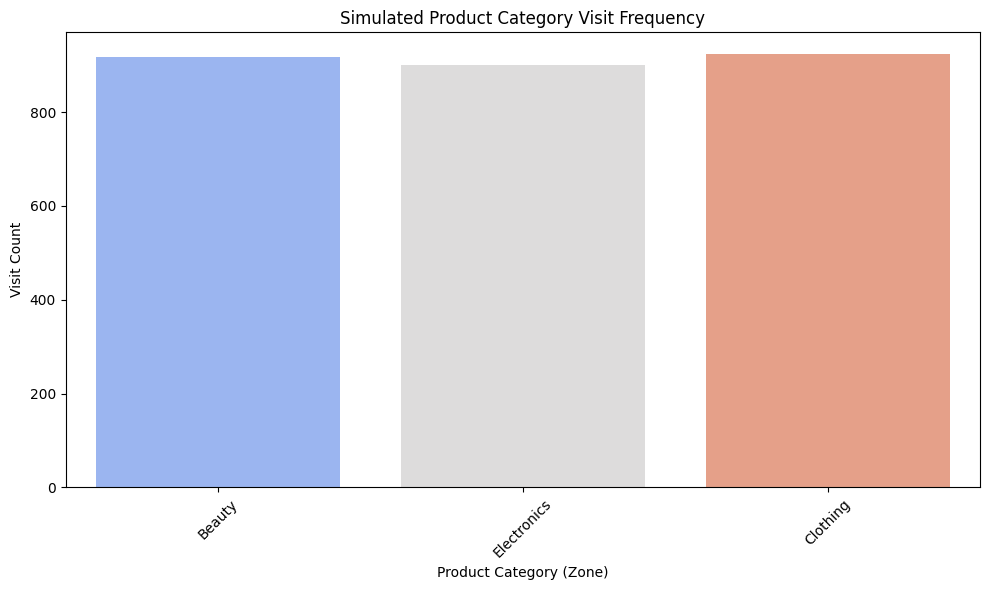


📈 Product Placement Suggestions:
- High traffic zones: Clothing, Beauty, Electronics → place promotions or high-margin items here.
- Low traffic zones: Beauty, Electronics → move near high traffic areas or along key paths.


In [ ]:
import pandas as pd
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("retail_sales_dataset.csv")
if "Product Category" not in df.columns:
    raise ValueError("Dataset must include a 'Product Category' column.")
categories = df['Product Category'].dropna().unique().tolist()

# === Step 2: Simulate Browsing Paths ===
def simulate_customer_path():
    path_length = random.randint(2, 5)  # between 2 and 5 zones
    return random.sample(categories, k=min(path_length, len(categories)))

# Simulate paths for 1000 customers
simulated_paths = [simulate_customer_path() for _ in range(1000)]

# === Step 3: Build Markov Chain (Transition Probabilities) ===
transitions = defaultdict(lambda: defaultdict(int))

for path in simulated_paths:
    for i in range(len(path) - 1):
        transitions[path[i]][path[i + 1]] += 1

# Normalize to get probability distribution
probabilities = {
    current: {
        next_cat: count / sum(next_steps.values())
        for next_cat, count in next_steps.items()
    }
    for current, next_steps in transitions.items()
}

# === Step 4: Predict Movement Path ===
def predict_path(start=None):
    if not start:
        start = random.choice(categories)
    path = [start]
    while len(path) < 5:
        current = path[-1]
        next_probs = probabilities.get(current, {})
        if not next_probs:
            break
        next_cat = random.choices(list(next_probs.keys()), weights=next_probs.values())[0]
        path.append(next_cat)
    return path

# Show an example predicted path
print("Example Predicted Path:")
print(" → ".join(predict_path()))

# === Step 5: Category Visit Frequency Visualization ===
# Count how often each category appears in simulated paths
category_visits = defaultdict(int)
for path in simulated_paths:
    for cat in path:
        category_visits[cat] += 1

# Bar plot of visit frequency
plt.figure(figsize=(10, 6))
sns.barplot(x=list(category_visits.keys()), y=list(category_visits.values()), palette='coolwarm')
plt.title("Simulated Product Category Visit Frequency")
plt.xlabel("Product Category (Zone)")
plt.ylabel("Visit Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Step 6: Product Placement Suggestion ===
print("\n📈 Product Placement Suggestions:")
sorted_visits = sorted(category_visits.items(), key=lambda x: x[1], reverse=True)
top_categories = [cat for cat, _ in sorted_visits[:3]]
low_categories = [cat for cat, _ in sorted_visits[-2:]]

print(f"- High traffic zones: {', '.join(top_categories)} → place promotions or high-margin items here.")
print(f"- Low traffic zones: {', '.join(low_categories)} → move near high traffic areas or along key paths.")
